<a href="https://colab.research.google.com/github/agentshanz/StudentGradePredictModel/blob/main/StudentGradePredictModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [38]:
df = pd.read_csv('student_exam_performance.csv')

In [39]:
df

,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,...,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,...,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,...,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,...,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,...,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU_099996,17,Male,Undergraduate,Public,Upper-Middle,NaN,Suburban,78.73,NaN,...,Medium,5,95,62,76.13,8.36,66.46,C,Pass,Medium
99996,STU_099997,14,Female,High School,Public,Upper-Middle,Bachelor,Suburban,75.70,2.98,...,Easy,24,94,91,84.29,8.68,96.54,A,Pass,High
99997,STU_099998,16,Female,High School,Public,Upper-Middle,High School,Suburban,84.69,3.27,...,Medium,24,85,65,62.32,9.97,74.66,C,Pass,Medium
99998,STU_099999,15,Female,High School,Private,High,Master,Rural,74.70,3.06,...,Medium,28,93,81,100.00,10.00,85.85,A,Pass,High


In [40]:
df.count()

,0
student_id,100000
age,100000
gender,100000
education_level,100000
school_type,100000
family_income,100000
parent_education,93474
urban_rural,100000
previous_exam_score,100000
previous_gpa,92207


In [41]:
df = df.drop(['student_id','age','gender','education_level','school_type','family_income','parent_education','urban_rural','previous_exam_score','previous_gpa','class_participation','study_environment','study_method','notes_quality','sleep_quality','daily_screen_time','break_frequency','stress_level','motivation_level','device_availability','questions_attempted','questions_correct','time_management_score','exam_score','pass_status','performance_level'],axis=1)

In [42]:
df.head(10)

,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,revision_frequency,practice_tests_completed,sleep_hours,physical_activity_hours,internet_access,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,exam_anxiety_level,performance_grade
0,81.49,65.18,4.94,2.63,0,1.75,Medium,Rarely,8,6.31,0.93,1,Low,2.15,Medium,27,9.39,A
1,NaN,76.53,3.42,2.64,0,1.97,Medium,Daily,10,6.81,0.21,1,Moderate,4.37,Easy,4,6.31,A
2,100.00,70.39,1.06,0.83,0,3.40,Low,Weekly,5,6.53,2.56,1,Low,1.43,Easy,28,9.87,B
3,84.91,75.06,7.89,5.51,0,1.94,Medium,Weekly,8,6.60,2.30,1,Low,3.69,Medium,16,9.68,B
4,88.21,61.54,2.63,2.29,0,0.58,Medium,Rarely,1,7.83,0.49,1,Moderate,1.97,Medium,28,10.00,D
5,97.11,65.46,3.18,1.67,1,1.02,Medium,Daily,6,8.83,1.64,1,Moderate,1.08,Hard,27,6.12,C
6,85.38,70.92,3.35,2.11,0,1.47,Medium,Weekly,6,7.16,0.71,1,Low,5.62,Hard,12,9.46,D
7,80.61,72.83,5.51,4.33,0,0.26,Low,Weekly,9,8.22,0.09,0,Moderate,4.78,Easy,7,10.00,A
8,86.47,70.12,2.42,1.65,1,6.23,High,Weekly,7,6.55,1.51,1,Low,2.01,Hard,14,8.34,F
9,89.61,61.53,1.26,0.78,0,2.86,Medium,Weekly,2,8.90,1.59,1,Low,8.40,Hard,4,8.49,F


In [43]:
df.describe()

,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,practice_tests_completed,sleep_hours,physical_activity_hours,internet_access,online_course_hours,exam_preparation_days,exam_anxiety_level
count,90137.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,84.616882,69.724405,2.995725,2.094970,0.299800,2.004763,5.509170,6.995102,2.487579,0.918760,2.999453,15.501440,8.927373
std,7.922485,12.127179,1.719466,1.266066,0.458173,2.005719,2.501131,1.200874,2.413386,0.273205,2.983732,8.644356,1.354875
min,46.340000,20.000000,0.500000,0.250000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,79.210000,61.480000,1.720000,1.170000,0.000000,0.580000,4.000000,6.180000,0.720000,1.000000,0.860000,8.000000,8.220000
50%,84.750000,69.570000,2.670000,1.840000,0.000000,1.380000,5.000000,7.000000,1.730000,1.000000,2.080000,16.000000,9.490000
75%,90.170000,77.920000,3.910000,2.730000,1.000000,2.770000,7.000000,7.810000,3.480000,1.000000,4.150000,23.000000,10.000000
max,100.000000,100.000000,12.000000,10.000000,1.000000,15.000000,20.000000,11.000000,12.000000,1.000000,20.000000,30.000000,10.000000


In [25]:
df.isna().sum()

,0
attendance_percentage,9863
assignment_completion_rate,0
study_hours_per_day,0
self_study_hours,0
private_tuition,0
online_learning_hours,0
study_consistency,0
revision_frequency,0
practice_tests_completed,0
sleep_hours,0


In [27]:
df['attendance_percentage'].describe()

,attendance_percentage
count,90137.000000
mean,84.616882
std,7.922485
min,46.340000
25%,79.210000
50%,84.750000
75%,90.170000
max,100.000000


In [44]:
df['attendance_percentage'] = df['attendance_percentage'].fillna(df['attendance_percentage'].mean())

In [47]:
df.isna().sum()

,0
attendance_percentage,0
assignment_completion_rate,0
study_hours_per_day,0
self_study_hours,0
private_tuition,0
online_learning_hours,0
study_consistency,0
revision_frequency,0
practice_tests_completed,0
sleep_hours,0


In [45]:
df

,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,revision_frequency,practice_tests_completed,sleep_hours,physical_activity_hours,internet_access,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,exam_anxiety_level,performance_grade
0,81.490000,65.18,4.94,2.63,0,1.75,Medium,Rarely,8,6.31,0.93,1,Low,2.15,Medium,27,9.39,A
1,84.616882,76.53,3.42,2.64,0,1.97,Medium,Daily,10,6.81,0.21,1,Moderate,4.37,Easy,4,6.31,A
2,100.000000,70.39,1.06,0.83,0,3.40,Low,Weekly,5,6.53,2.56,1,Low,1.43,Easy,28,9.87,B
3,84.910000,75.06,7.89,5.51,0,1.94,Medium,Weekly,8,6.60,2.30,1,Low,3.69,Medium,16,9.68,B
4,88.210000,61.54,2.63,2.29,0,0.58,Medium,Rarely,1,7.83,0.49,1,Moderate,1.97,Medium,28,10.00,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,89.670000,60.97,1.16,0.68,0,1.56,Medium,Weekly,7,7.00,4.29,1,High,6.43,Medium,5,8.36,C
99996,83.870000,94.38,8.59,6.63,0,0.49,Medium,Weekly,12,6.73,3.60,1,Low,4.34,Easy,24,8.68,A
99997,89.570000,71.28,2.45,2.20,0,4.33,High,Rarely,5,7.20,1.62,1,Moderate,11.91,Medium,24,9.97,C
99998,92.610000,69.26,4.77,3.92,1,0.41,Medium,Weekly,7,8.37,2.21,1,Moderate,0.55,Medium,28,10.00,A


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

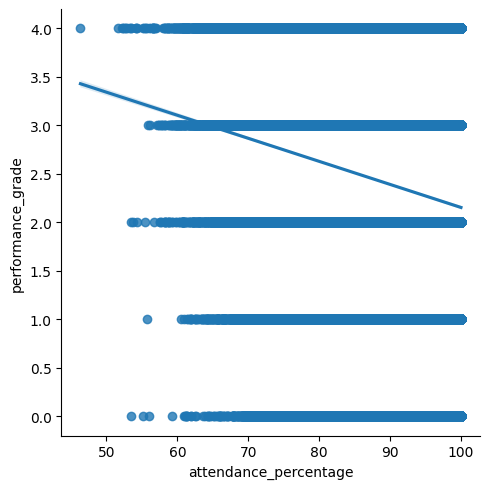

In [66]:
sns.lmplot(x='attendance_percentage', y='performance_grade', data=df)

<Axes: xlabel='exam_preparation_days', ylabel='performance_grade'>

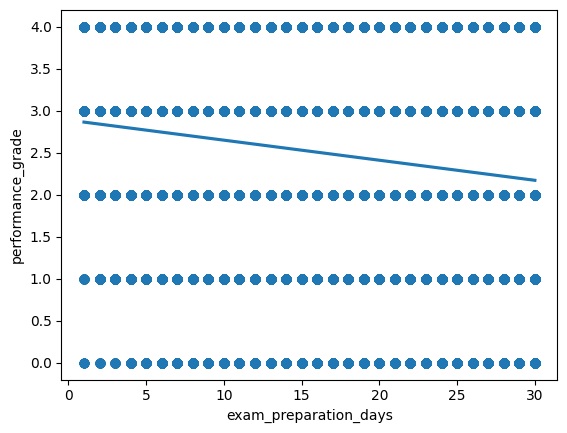

In [68]:
sns.regplot(x='exam_preparation_days', y='performance_grade', data=df)

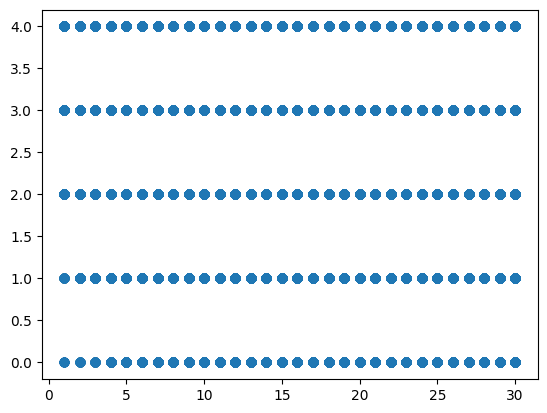

In [72]:
plt.scatter(df['exam_preparation_days'], df['performance_grade'])
plt.show()

In [48]:
from sklearn.preprocessing import LabelEncoder

In [49]:
le = LabelEncoder()

In [61]:
df[['study_consistency', 'revision_frequency', 'educational_app_usage', 'exam_difficulty','performance_grade']] = df[['study_consistency', 'revision_frequency', 'educational_app_usage', 'exam_difficulty','performance_grade']].apply(le.fit_transform)

In [63]:
le.classes_

array([0, 1, 2, 3, 4])

In [62]:
df

,attendance_percentage,assignment_completion_rate,study_hours_per_day,self_study_hours,private_tuition,online_learning_hours,study_consistency,revision_frequency,practice_tests_completed,sleep_hours,physical_activity_hours,internet_access,educational_app_usage,online_course_hours,exam_difficulty,exam_preparation_days,exam_anxiety_level,performance_grade
0,81.490000,65.18,4.94,2.63,0,1.75,2,1,8,6.31,0.93,1,1,2.15,2,27,9.39,0
1,84.616882,76.53,3.42,2.64,0,1.97,2,0,10,6.81,0.21,1,2,4.37,0,4,6.31,0
2,100.000000,70.39,1.06,0.83,0,3.40,1,2,5,6.53,2.56,1,1,1.43,0,28,9.87,1
3,84.910000,75.06,7.89,5.51,0,1.94,2,2,8,6.60,2.30,1,1,3.69,2,16,9.68,1
4,88.210000,61.54,2.63,2.29,0,0.58,2,1,1,7.83,0.49,1,2,1.97,2,28,10.00,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,89.670000,60.97,1.16,0.68,0,1.56,2,2,7,7.00,4.29,1,0,6.43,2,5,8.36,2
99996,83.870000,94.38,8.59,6.63,0,0.49,2,2,12,6.73,3.60,1,1,4.34,0,24,8.68,0
99997,89.570000,71.28,2.45,2.20,0,4.33,0,1,5,7.20,1.62,1,2,11.91,2,24,9.97,2
99998,92.610000,69.26,4.77,3.92,1,0.41,2,2,7,8.37,2.21,1,2,0.55,2,28,10.00,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.2)

In [ ]:
x_test

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
506,507,0,5.1,80.6,7.7,1,0,0,51.1,74.5
660,661,0,4.5,85.0,8.2,1,0,0,71.9,95.2
769,770,1,5.0,78.8,4.8,1,0,0,83.5,98.4
317,318,1,1.4,96.1,8.0,0,1,0,75.7,79.2
334,335,0,4.0,90.1,9.1,1,0,0,69.9,88.7
...,...,...,...,...,...,...,...,...,...,...
39,40,1,5.6,65.3,7.4,1,1,0,85.5,91.6
214,215,1,4.6,83.2,4.5,1,1,0,58.0,84.7
657,658,1,3.4,86.5,7.1,1,1,0,95.5,100.0
206,207,0,4.2,89.4,6.7,1,1,1,79.7,100.0


In [ ]:
y_test

,final_grade
506,C
660,A
769,A
317,C
334,B
...,...
39,A
214,B
657,A
206,A


In [ ]:
x_train

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
421,422,0,2.8,90.1,5.8,0,1,0,84.1,89.6
197,198,0,6.9,85.6,8.3,1,1,0,67.3,92.2
990,991,0,2.5,81.4,6.5,1,0,0,81.8,81.9
60,61,1,4.0,79.7,7.2,1,1,0,67.4,80.4
871,872,0,4.1,80.8,5.9,1,1,1,76.9,92.6
...,...,...,...,...,...,...,...,...,...,...
450,451,0,5.8,73.6,9.1,0,1,0,54.2,77.9
674,675,0,4.7,93.5,7.2,1,1,0,49.1,83.8
763,764,0,2.2,68.6,5.7,1,1,0,58.3,81.2
556,557,0,4.5,87.7,7.6,1,1,0,71.7,80.8


In [ ]:
y_train

,final_grade
421,B
197,A
990,B
60,B
871,A
...,...
450,C
674,B
763,B
556,B


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
le = LogisticRegression(max_iter=100)

In [ ]:
le.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predict = le.predict(x_test)

In [ ]:
y_predict

array(['B', 'A', 'A', 'C', 'B', 'A', 'A', 'A', 'C', 'A', 'B', 'A', 'A',
       'B', 'B', 'C', 'A', 'B', 'C', 'D', 'B', 'A', 'B', 'B', 'A', 'C',
       'A', 'C', 'B', 'A', 'D', 'C', 'B', 'B', 'B', 'C', 'A', 'C', 'C',
       'B', 'B', 'B', 'B', 'A', 'B', 'B', 'B', 'C', 'C', 'B', 'A', 'A',
       'A', 'A', 'A', 'A', 'A', 'C', 'B', 'B', 'A', 'A', 'A', 'B', 'C',
       'D', 'A', 'C', 'B', 'B', 'B', 'C', 'C', 'A', 'A', 'C', 'B', 'C',
       'D', 'A', 'B', 'B', 'B', 'A', 'A', 'A', 'C', 'C', 'A', 'C', 'D',
       'A', 'A', 'B', 'C', 'B', 'A', 'C', 'B', 'D', 'A', 'A', 'B', 'A',
       'C', 'A', 'B', 'A', 'B', 'B', 'C', 'C', 'B', 'C', 'A', 'A', 'A',
       'C', 'B', 'C', 'C', 'C', 'C', 'B', 'D', 'D', 'A', 'A', 'B', 'A',
       'B', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'A', 'A', 'D',
       'B', 'B', 'A', 'B', 'B', 'C', 'D', 'B', 'C', 'B', 'C', 'B', 'D',
       'A', 'B', 'B', 'B', 'C', 'B', 'D', 'A', 'C', 'A', 'A', 'A', 'B',
       'B', 'B', 'C', 'B', 'A', 'B', 'A', 'A', 'C', 'B', 'B', 'A

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           A       0.55      0.68      0.61       218
           B       0.45      0.43      0.44       284
           C       0.52      0.47      0.50       211
           D       0.52      0.49      0.51        75
           F       0.00      0.00      0.00        12

    accuracy                           0.51       800
   macro avg       0.41      0.41      0.41       800
weighted avg       0.50      0.51      0.50       800



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
